In [2]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm

In [5]:
#function
#ABS
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=3e-6):
    d = H_q.shape[0]
    
    # 构造复能量矩阵 (简化的写法，等价于你的 EI_gai)
    EI_gai = (E + 1j * eta) * np.eye(d, dtype=complex)

    # 1. 计算左引线自能
    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # 2. 计算右引线自能
    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法提取 G_00 和 G_01
    # ==========================================
    ALR = EI_gai - H_q
    V = T_12
    
    # 3. Right-to-Left 扫掠：只记录向右连通的等效格林函数 gR
    gR = np.zeros((N, d, d), dtype=complex)
    gR[N-1] = np.linalg.inv(ALR - Sigma_R)
    
    # 从 N-2 往 1 递推，把右侧的物理效应不断折叠为等效自能
    for n in range(N-2, 0, -1):
        gR[n] = np.linalg.inv(ALR - V @ gR[n+1] @ V.conj().T)
        
    # 4. 算出真正的左上角 4x4 格林函数 G_00 (原 G_DD_r[0:4, 0:4])
    # 在最左侧 n=0 处，加上左引线的自能 Sigma_L
    G_00 = np.linalg.inv(ALR - V @ gR[1] @ V.conj().T - Sigma_L)
    
    # 5. 算出左上角右侧相邻的 4x4 非对角块 G_01 (原 G_DD_r[0:4, 4:8])
    # 根据 Dyson 方程，G_01 = G_00 * V_01 * gR_1
    #G_01 = G_00 @ V @ gR[1]

    # 返回你需要的结果 (去掉了庞大无用的 A_DD)
    return G_00, G_00, Sigma_R, Sigma_L

def bufeng(G_00):
    d = H_q.shape[0]
    yigeshu=np.trace(G_00)
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list


#current
def Gr_DD_MS(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    
    # 构造松原频率复能量矩阵
    # 假设外部已经定义了 s0 = np.eye(2, dtype=complex)
    EI_gai =  np.eye(d, dtype=complex) * (1j * wn)

    # 1. 计算左引线自能
    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # 2. 计算右引线自能
    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法提取 Matsubara G_00, G_01 和 G_10
    # ==========================================
    ALR = EI_gai - H_q
    V = T_12

    # 特殊情况防错：如果 N=1，只有1个格点
    if N == 1:
        G_00 = np.linalg.inv(ALR - Sigma_L - Sigma_R)
        G_01 = np.zeros((d, d), dtype=complex)
        G_10 = np.zeros((d, d), dtype=complex)
        return G_00, G_01, G_10, Sigma_R, Sigma_L

    # 3. Right-to-Left 扫掠：只记录向右连通的等效松原格林函数 gR
    gR = np.zeros((N, d, d), dtype=complex)
    gR[N-1] = np.linalg.inv(ALR - Sigma_R)
    
    # 从 N-2 往 1 递推，把右侧的物理效应不断折叠为等效自能
    for n in range(N-2, 0, -1):
        gR[n] = np.linalg.inv(ALR - V @ gR[n+1] @ V.conj().T)
        
    # 4. 算出真正的左上角 4x4 松原格林函数 G_00
    # 在最左侧 n=0 处，加上左引线的自能 Sigma_L
    G_00 = np.linalg.inv(ALR - V @ gR[1] @ V.conj().T - Sigma_L)
    
    # 5. 算出右侧相邻的非对角块 G_01
    # 公式: G_{0,1} = G_{0,0} * V * gR_1
    G_01 = G_00 @ V @ gR[1]

    # 6. 算出下方相邻的非对角块 G_10
    # 公式: G_{1,0} = gR_1 * V^\dagger * G_{0,0}
    G_10 = gR[1] @ V.conj().T @ G_00

    # 返回优化后的结果 
    return G_00, G_01, G_10, Sigma_R, Sigma_L

def J_wn(G_01, G_10, T_12):
    d = T_12.shape[0]

    G_q_q1 = G_01
    G_q1_q = G_10

    Jmat = T_12.conj().T @ G_q_q1 - G_q1_q @ T_12
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT*(-1)
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        _, G_01, G_10, _, _ = Gr_DD_MS(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_01, G_10, T_12))
    return (J_sum)

def J_of_phi(phi):
    H_l = H_onstie(m,B,a   ,uS_set,Delta,0,    int(yw/a),4,    A)
    H_q = H_onstie(m,B,a   ,uN_set,0,0,    int(yw/a),4,    A)
    H_r = H_onstie(m,B,a   ,uS_set,Delta,phi,    int(yw/a),4,    A)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,int(xL/a))
    return Jphi

def find_J_extreme_fmin(phi_min=0*np.pi, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-4, ftol=1e-4,
                       round_digits=6):

    phi_guesses = np.linspace(phi_min, phi_max, N_guess)

    max_list = []
    min_list = []

    for phi0 in phi_guesses:

        # 最大值
        rmax = fmin(lambda phi: -J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        max_list.append(rmax[0])

        # 最小值
        rmin = fmin(lambda phi: J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        min_list.append(rmin[0])

    phi_max_list = np.unique(np.round(max_list, round_digits))
    phi_min_list = np.unique(np.round(min_list, round_digits))

    J_max = max(J_of_phi(phi) for phi in phi_max_list)
    J_min = min(J_of_phi(phi) for phi in phi_min_list)


    J_max = -np.inf
    phi_at_Jmax = None

    for phi in phi_max_list:
        val = J_of_phi(phi)
        if val > J_max:
            J_max = val
            phi_at_Jmax = phi

    J_min = np.inf
    phi_at_Jmin = None

    for phi in phi_min_list:
        val = J_of_phi(phi)
        if val < J_min:
            J_min = val
            phi_at_Jmin = phi

    yinzi =abs(abs(J_max) - abs(J_min)) / (abs(J_max) + abs(J_min))

    return J_max, phi_at_Jmax/np.pi, J_min, phi_at_Jmin/np.pi, yinzi


In [32]:
#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m,B,a):
    return (m-4*B/(a**2))*sz

def h_x(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sx

def h_y(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sy

def h_onstie(m,B,a   ,u,Delta,chaodaojiao):
    HX_block=h_k(m,B,a)-u*s0
    Delta_X= 1j *Delta * np.exp(1j*chaodaojiao) *  sy
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])

def t_x(B,a,A):
    TX_block=h_x(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def t_y(B,a,A):
    TX_block=h_y(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def H_onstie(m,B,a   ,u_set,Delta,chaodaojiao,    yshumu,Nd,    A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=h_onstie(m,B,a   ,u_set[i],Delta,chaodaojiao)

        if i < yshumu-1:
            H[i][i+1] = t_y(B,a,A)

        if i > 0:
            H[i][i-1] = t_y(B,a,A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B,a,A,   yshumu,Nd):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=t_x(B,a,A)

    #
    H = np.block(H)
    return H

m=0.5
A=1  #/(2*np.pi)*(2*np.pi)
B=1  #/(2*np.pi)*(2*np.pi)

delta=0.1
chaodaojiao=0
T_Tc=0.2
Delta = delta* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

dianshubei=1
shumu=int(np.floor(50*delta/(2*np.pi*KBT)))*dianshubei
KBT=2 * delta * T_Tc / 3.5

a=1
yw=3*a
xL=2*a
N=int(xL/a)

uN=0
uS=0.03
Ey = 0.08/100

Ny = int(yw/a)
uN_set = []
for i in range(Ny):
    uN_set.append(uN) #- Ey * (i - Ny/2))
uS_set=[]
for i in range(Ny):
    uS_set.append(uS - Ey * (i - Ny/2))
#print(uN_set[99])
#print(uS_set[99])

H_q= H_onstie(m,B,a   ,uN_set,0,0,    int(yw/a),4,    A)
T_12= H_hop(B,a,A,   int(yw/a),4)


H_r= H_onstie(m,B,a   ,uS_set,Delta,0,    int(yw/a),4,    A)
T_r= H_hop(B,a,A,   int(yw/a),4).conj().T

H_l= H_onstie(m,B,a   ,uS_set,Delta,0,    int(yw/a),4,    A)
T_l= H_hop(B,a,A,   int(yw/a),4)

T_LD=H_hop(B,a,A,   int(yw/a),4).conj().T
T_RD=H_hop(B,a,A,   int(yw/a),4)
#print(H_q.shape)

In [34]:
#核心——二极管因子（Jmax-phimax,Jmin-phimin）
shumu=int(np.floor(50*delta/(2*np.pi*KBT)))*dianshubei
print('n*2*np.pi*KBT/Delta=',shumu*2*np.pi*KBT/Delta)
jjalpi=J_of_phi(0.5*np.pi)
print('这时J(phi/2)=',jjalpi)

shumu=int(np.floor(50*delta/(2*np.pi*KBT)))*dianshubei+1
print('n*2*np.pi*KBT/Delta=',shumu*2*np.pi*KBT/Delta)
jjalpi2=J_of_phi(0.5*np.pi)
print('这时J(phi/2)=',jjalpi2)


alnalkna=abs(abs(jjalpi2)-abs(jjalpi))/(abs(jjalpi2)+abs(jjalpi))
print('因子差=',alnalkna)

shumu=int(np.floor(50*delta/(2*np.pi*KBT)))*dianshubei


n*2*np.pi*KBT/Delta= 49.6415440275511
这时J(phi/2)= -3.873849870666128e-05
n*2*np.pi*KBT/Delta= 50.36098669461706
这时J(phi/2)= -3.8739023880611874e-05
因子差= 6.77840402034601e-06


In [35]:
#J vs phi
phi_list = np.linspace(0, 2*np.pi, 21) #和下文配备
J_list = []
for phi in phi_list:
    chaodaojiao = phi
    H_r = H_onstie(m,B,a   ,uS_set,Delta,chaodaojiao,    int(yw/a),4,    A)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N)

    J_list.append(Jphi)

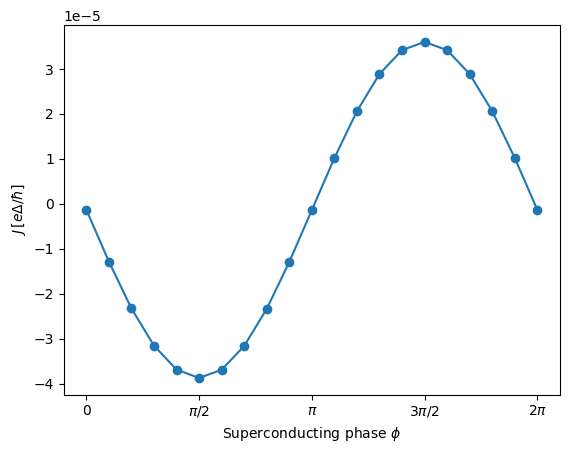

In [36]:
plt.figure()
plt.plot(phi_list, J_list, marker='o')
plt.xlabel(r'Superconducting phase $\phi$')
plt.ylabel(r'$J\,[e\Delta/\hbar]$')
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)

plt.show()

<>:45: SyntaxWarning: invalid escape sequence '\D'
<>:45: SyntaxWarning: invalid escape sequence '\D'
C:\Users\taoji\AppData\Local\Temp\ipykernel_38640\3622253455.py:45: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('E/$\Delta$')


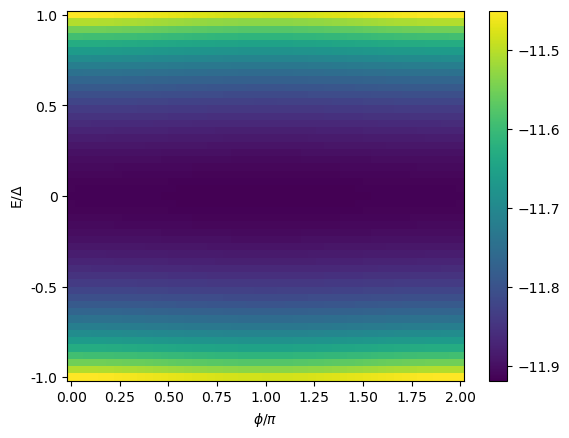

In [38]:
#ABS——态密度扫描
shangxia=1

num_ef = 50
efmin = -Delta*shangxia
efmax = Delta*shangxia
def_ = (efmax - efmin) / num_ef
num_phi = 50
phi_min = 0
phi_max = 2 * np.pi
dphi = (phi_max - phi_min) / num_phi

# Initialize grids
ef_plot = np.zeros(num_ef + 1)
phi_plot = np.zeros(num_phi + 1)
ABS = np.zeros((num_ef + 1, num_phi + 1))

for jj in range(num_ef + 1):
    ef = efmin + def_ * jj
    ef_plot[jj] = ef
    for ii in range(num_phi + 1):
        phi = phi_min + dphi * ii
        phi_plot[ii] = phi / np.pi
        
        # Update Delta and H_l, H_r based on phi
        H_r= H_onstie(m,B,a   ,uS_set,Delta,phi,    int(yw/a),4,    A)
        
        # Compute G_DD_r
        G_00, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, ef
        )
        
        # Compute ABS (bufeng)
        ABS[jj, ii] = bufeng(G_00)

# Figure
plt.figure()
X, Y = np.meshgrid(phi_plot, ef_plot)
plt.pcolormesh(X, Y, np.log(ABS + 1e-10), shading='auto')  # Added small epsilon to avoid log(0)
plt.colorbar(location='right')
plt.xlabel(r'$\phi$/$\pi$')

plt.ylabel('E/$\Delta$')
plt.yticks(
    [efmin, efmin/2, 0,efmax/2, efmax],
    [efmin/Delta, efmin/Delta/2, 0,efmax/Delta/2, efmax/Delta]
)
plt.axis('square')
plt.axis('tight')
plt.show()